In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pandas as pd
from planetmagfields import Planet
from model import ForwardModel, InverseModel, lcurve_distance
from tqdm import tqdm

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = True
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

## Read data

In [28]:
# df = pd.read_csv('./pds_data/uranus48s.csv')

# theta = df['Colatitude'] * np.pi / 180
# phi = (df['Longitude'] % 360) * np.pi / 180
# r = df['Radius']
# keys = ['Br', 'Btheta', 'Bphi']

RU = 25559  # km
mag = pd.concat([pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860124_ASC.csv'),
                 pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860125_ASC.csv')],
                ignore_index=True)
pos = pd.read_csv('./pds_data/1.92s/vg2_positions_1_92s.csv')
mag['PDSTIME'] = pd.to_datetime(mag.PDSTIME, format='ISO8601', utc=True)
pos['PDSTIME'] = pd.to_datetime(pos.PDSTIME, format='ISO8601', utc=True)


df = mag.merge(pos, on='PDSTIME', how='inner')
r = pos['radius']/RU
theta = pos['colatitude']
phi = pos['longitude']

## Inverse Modeling

In [29]:
mask = r <= 12

r = r[mask]; theta = theta[mask]; phi = phi[mask]
df = df[mask]

keys = ['BR', 'BTheta', 'BPhi']

## Find optimal $\alpha$

100%|██████████| 500/500 [00:04<00:00, 102.86it/s]


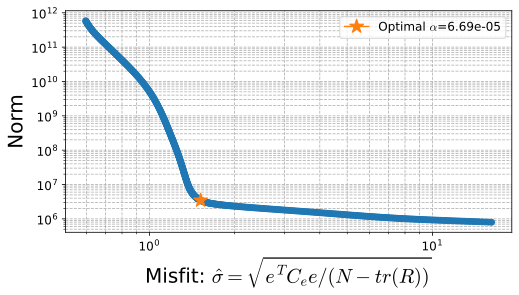

In [31]:
# # Create model
M_inv = InverseModel(lmax=16, r=r, theta=theta, phi=phi,
                 br=df[keys[0]],
                 btheta=df[keys[1]],
                 bphi=df[keys[2]],
                 smoothing_norm='B2',
                 include_external=True,
                 a=1,b=0.8,c=0.7)

# Define alpha range
alpha_arr = np.logspace(-10, -1, 500)

# Plot trade-off curve
misfit_arr = []
norm_arr = []
for alpha in tqdm(alpha_arr):
    M_inv.solve(alpha=alpha)
    misfit_arr.append(M_inv.misfit_norm)
    norm_arr.append(M_inv.norm_value_ohmic)

# Find optimal alpha (e.g., using L-curve corner)
# We find max curvature point on log-log trade-off curve
# optimal_idx, optimal_alpha, _ = lcurve_knee(alpha_arr, misfit_arr, norm_arr)
optimal_idx, optimal_alpha = lcurve_distance(alpha_arr, misfit_arr, norm_arr)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
ax.loglog(misfit_arr, norm_arr, marker='o')
ax.loglog(misfit_arr[optimal_idx], norm_arr[optimal_idx], marker='*', markersize=15, label=r'Optimal $\alpha$=%.2e' % optimal_alpha)
ax.legend()
ax.set_xlabel(r'Misfit: $\hat{\sigma} = \sqrt{e^T C_e e/(N-tr(R))}$')
ax.set_ylabel('Norm')
# ax.set_title('Trade-off Curve')
ax.grid(True, which='both', ls='--')
if savefigs:
    plt.savefig('figures/tradeoff_curve.png', dpi=300, bbox_inches='tight')
plt.show()

M_inv.solve(alpha=optimal_alpha)

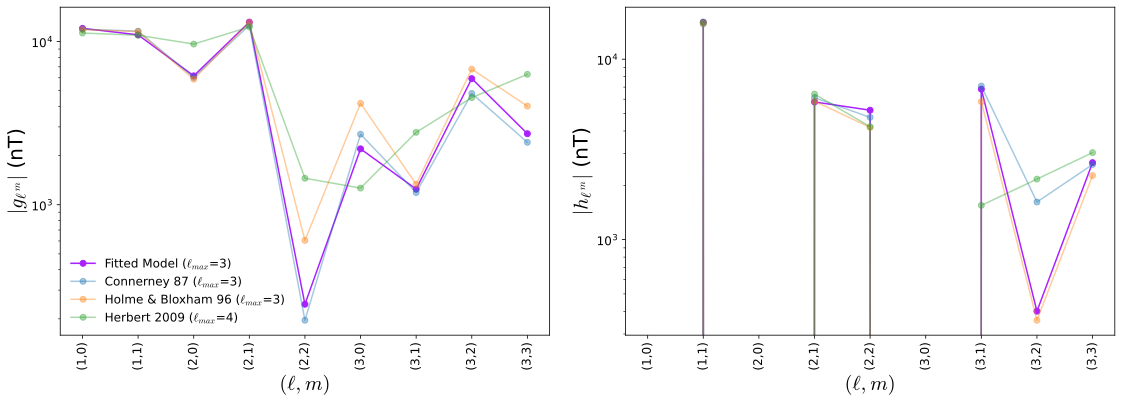

In [32]:
lmax_plot = 3                                  # degree to show the fitted model to
n = lmax_plot * (lmax_plot + 3) // 2           # number of (l,m) pairs, = 20
labels = ['(%d,%d)' % (l, m) for l in range(1, lmax_plot+1) for m in range(l+1)]

pl1 = Planet(name='Uranus', model='connerney1987', info=False, units='nT')
pl2 = Planet(name='Uranus', model='holme1996', info=False, units='nT')
pl3 = Planet(name='Uranus', model='herbert2009', info=False, units='nT')
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(16,6))
for i in [0,1]:
    if i == 0:
        coeff = M_inv.glm[:n]
        coeff_ref1 = pl1.glm[1:n+1]
        coeff_ref2 = pl2.glm[1:n+1]
        coeff_ref3 = pl3.glm[1:n+1]
        ylabel = r'$|g_{\ell^m}|$ (nT)'
    if i == 1:
        coeff = M_inv.hlm[:n]
        coeff_ref1 = pl1.hlm[1:n+1]
        coeff_ref2 = pl2.hlm[1:n+1]
        coeff_ref3 = pl3.hlm[1:n+1]
        ylabel = r'$|h_{\ell^m}|$ (nT)'

    ax[i].plot(np.abs(coeff),'-o',label=r'Fitted Model ($\ell_{max}$=%d)' % lmax_plot,color='#aa21ff')
    ax[i].plot(np.abs(coeff_ref1),'-o',label=r'Connerney 87 ($\ell_{max}$=%d)' % pl1.lmax,alpha=0.4)
    ax[i].plot(np.abs(coeff_ref2),'-o',label=r'Holme & Bloxham 96 ($\ell_{max}$=%d)' % pl2.lmax,alpha=0.4)
    ax[i].plot(np.abs(coeff_ref3),'-o',label=r'Herbert 2009 ($\ell_{max}$=%d)' % pl3.lmax,alpha=0.4)
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$(\ell,m)$')
    ax[i].set_xticks(np.arange(n))
    ax[i].set_xticklabels(labels, rotation=90)
    ax[i].set_ylabel(ylabel)

ax[0].legend(frameon=False)
fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_fitted_gauss_coefficients.png', dpi=300)
plt.show()

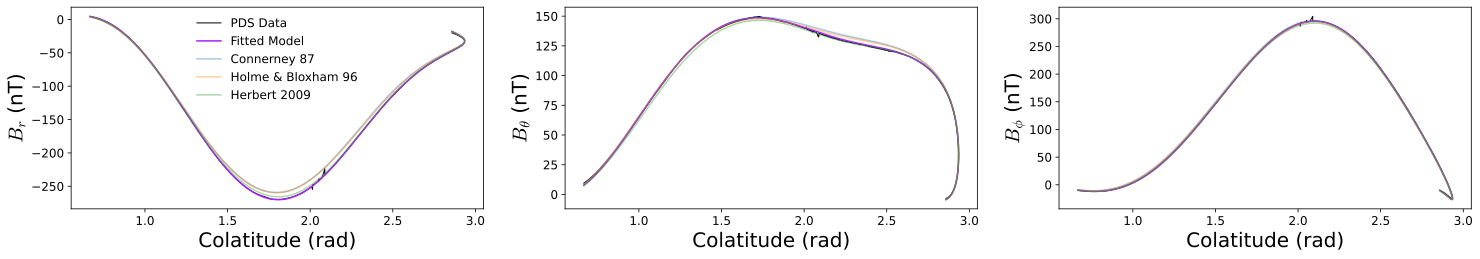

In [33]:
#Test all forward models:

b = np.real(M_inv.A @ M_inv.coeffs)

# Rearrange published coefficients into same format as M_inv.coeffs
def ref_b(pl):
    coeffs = np.zeros(M_inv.ncoeffs)
    for l in range(1, min(M_inv.lmax, pl.lmax) + 1):
        for m in range(l + 1):
            # Get coefficient from pl using pl's indexing
            coeffs[M_inv.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

            if m > 0:
                coeffs[M_inv.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

    return M_inv.A @ coeffs

# Same colours as the coefficient plot
models = [(b,          'Fitted Model',       '#aa21ff', 1.0),
          (ref_b(pl1), 'Connerney 87',       'C0',      0.4),
          (ref_b(pl2), 'Holme & Bloxham 96', 'C1',      0.4),
          (ref_b(pl3), 'Herbert 2009',       'C2',      0.4)]

ylabels = [r'$B_r$ (nT)', r'$B_\theta$ (nT)', r'$B_\phi$ (nT)']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(21, 4), sharex=True)
for i in [0, 1, 2]:
    ax[i].plot(theta, df[keys[i]], label='PDS Data', color='k', lw=1)
    for b_mod, label, color, alpha in models:
        # b is ordered [Br, Btheta, Bphi] per point, so i::3 picks component i
        ax[i].plot(theta, b_mod[i::3], label=label, color=color, alpha=alpha)
    ax[i].set_ylabel(ylabels[i])
    ax[i].set_xlabel('Colatitude (rad)')

ax[0].legend(frameon=False)
fig.tight_layout()

if savefigs:
    plt.savefig('figures/uranus_forward_model.png', dpi=300)
plt.show()

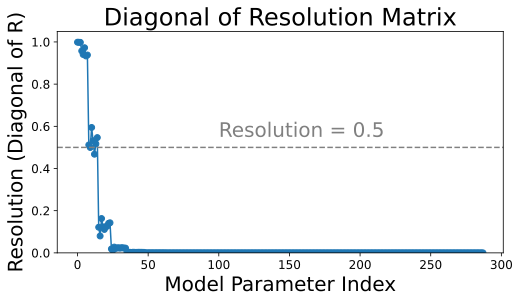

In [34]:
# Plot resolution matrix like Holme & Bloxham 1996
M_inv.resolution_matrix(alpha=optimal_alpha)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(np.diag(M_inv.R)[:-3], marker='o')
ax.set_xlabel('Model Parameter Index')
ax.set_ylabel('Resolution (Diagonal of R)')
ax.set_title('Diagonal of Resolution Matrix')

ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--')
ax.text(100, 0.55, 'Resolution = 0.5', color='gray', fontsize=20)

if M_inv.lmax < 5:
    ax.set_xticks(np.arange(M_inv.ncoeffs))
    if M_inv.lmax == 3:
        ax.set_xticklabels([r'$g_{10}$',r'$g_{11}$',r'$h_{11}$',
                               r'$g_{20}$',r'$g_{21}$',r'$g_{22}$',r'$h_{21}$',r'$h_{22}$',
                               r'$g_{30}$',r'$g_{31}$',r'$g_{32}$',r'$g_{33}$',r'$h_{31}$',r'$h_{32}$',r'$h_{33}$',
                               r'$G_{10}$',r'$G_{11}$',r'$H_{11}$'])
    elif M_inv.lmax == 4:
        ax.set_xticklabels([r'$g_{10}$',r'$g_{11}$',r'$h_{11}$',
                               r'$g_{20}$',r'$g_{21}$',r'$g_{22}$',r'$h_{21}$',r'$h_{22}$',
                               r'$g_{30}$',r'$g_{31}$',r'$g_{32}$',r'$g_{33}$',r'$h_{31}$',r'$h_{32}$',r'$h_{33}$',
                               r'$g_{40}$',r'$g_{41}$',r'$g_{42}$',r'$g_{43}$',r'$g_{44}$',r'$h_{41}$',r'$h_{42}$',r'$h_{43}$',r'$h_{44}$',
                               r'$G_{10}$',r'$G_{11}$',r'$H_{11}$'])
    ax.grid()


if savefigs:
    plt.savefig('figures/uranus_resolution_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

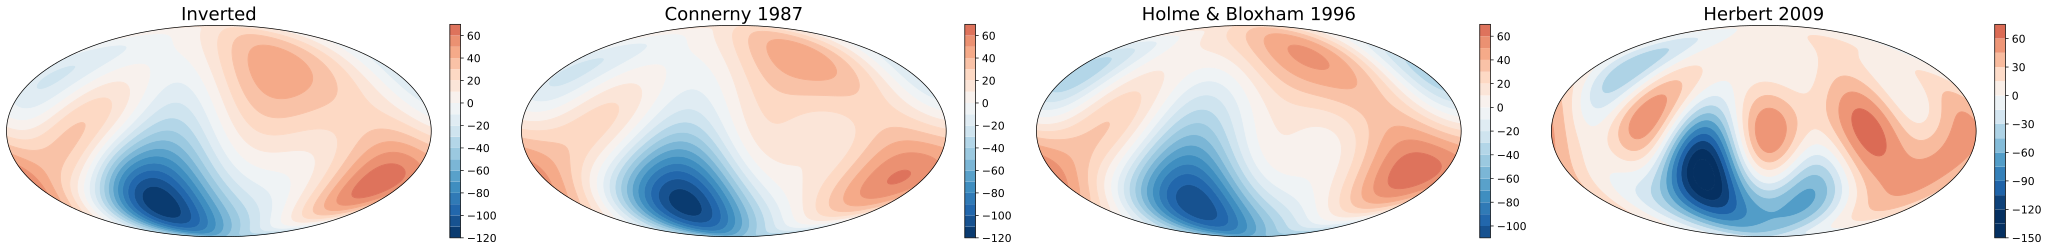

In [35]:
# Plot map of Br, keeping only well-resolved coefficients
import cartopy.crs as ccrs
from planetmagfields.libgauss import get_grid

p2D, th2D, ph, th = get_grid()

phi = p2D.flatten()
theta = th2D.flatten()
r = np.ones_like(phi)

lon2D = (p2D - np.pi) * 180 / np.pi
lat2D = (np.pi/2 - th2D) * 180 / np.pi

M_fwd = ForwardModel(lmax=M_inv.lmax, r=r, theta=theta, phi=phi,
                     glm=M_inv.glm, hlm=M_inv.hlm,
                     idx_g=M_inv.idx_g, idx_h=M_inv.idx_h)
Br = M_fwd.br.reshape(p2D.shape)/1e3

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(32,4), subplot_kw=dict(projection=ccrs.Mollweide()))
im1 = ax[0].contourf(lon2D,lat2D,Br, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-120, vmax=120)
im2 = ax[1].contourf(lon2D,lat2D,pl1.Br/1e3, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-120, vmax=120)
im3 = ax[2].contourf(lon2D,lat2D,pl2.Br/1e3, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-120, vmax=120)
im4 = ax[3].contourf(lon2D,lat2D,pl3.Br/1e3, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-120, vmax=120)

im1.set_edgecolor('face')
im2.set_edgecolor('face')
im3.set_edgecolor('face')
im4.set_edgecolor('face')

ax[0].set_title("Inverted",fontsize=20)
ax[1].set_title("Connerny 1987",fontsize=20)
ax[2].set_title("Holme & Bloxham 1996",fontsize=20)
ax[3].set_title("Herbert 2009",fontsize=20)
fig.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.04)
fig.colorbar(im4, ax=ax[3], fraction=0.046, pad=0.04)
fig.tight_layout()
if savefigs:
    plt.savefig("figures/uranus_map_comparison.png",dpi=300,bbox_inches='tight')
plt.show()